# Lotka Volterra (4 parameters) test case  

In [1]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from time import perf_counter
import pandas
import pickle
import os
import keras
import tensorflow as tf
import sys
from module_utils import * 
sys.path.append('../utils')
from Structure import *

from data_collection import *
from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)



True

In [2]:
# introduction of a seed for reproducibility purposes
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

In [3]:
import itertools

# Define the intervals and number of points
num_points = 5  # Number of points in each linspace (adjust as needed)

first_interval = np.linspace(2.1, 3, num_points)
second_interval = np.linspace(0.9, 1.5, num_points)
third_interval = np.linspace(0.9, 1.5, num_points)
fourth_interval = np.linspace(1., 2.1, num_points)
# Generate all combinations using itertools.product
combinations = list(itertools.product(first_interval, second_interval, third_interval, fourth_interval))

# Convert the combinations to a numpy array
combinations_array = np.array(combinations)[0:30,:]

# Shuffle the rows of the array
np.random.shuffle(combinations_array)

print(combinations_array)



num_params=4
params_val=combinations_array[0:6,:]

# Shuffle the rows of the array
np.random.shuffle(combinations_array)

print(combinations_array)

params=combinations_array[0:9,:]


[[2.1   0.9   1.5   1.   ]
 [2.1   0.9   1.05  1.55 ]
 [2.1   0.9   1.05  1.   ]
 [2.1   0.9   0.9   1.55 ]
 [2.1   0.9   0.9   1.825]
 [2.1   0.9   1.5   1.275]
 [2.1   0.9   1.2   1.825]
 [2.1   1.05  0.9   1.55 ]
 [2.1   0.9   1.2   1.55 ]
 [2.1   0.9   0.9   1.275]
 [2.1   0.9   1.35  2.1  ]
 [2.1   0.9   1.2   2.1  ]
 [2.1   0.9   1.35  1.825]
 [2.1   0.9   1.05  1.275]
 [2.1   0.9   1.2   1.275]
 [2.1   0.9   1.5   1.825]
 [2.1   0.9   1.5   2.1  ]
 [2.1   1.05  0.9   1.825]
 [2.1   0.9   1.5   1.55 ]
 [2.1   0.9   1.2   1.   ]
 [2.1   1.05  0.9   1.275]
 [2.1   1.05  0.9   2.1  ]
 [2.1   0.9   1.05  1.825]
 [2.1   1.05  0.9   1.   ]
 [2.1   0.9   1.35  1.275]
 [2.1   0.9   1.35  1.55 ]
 [2.1   0.9   0.9   1.   ]
 [2.1   0.9   1.35  1.   ]
 [2.1   0.9   0.9   2.1  ]
 [2.1   0.9   1.05  2.1  ]]
[[2.1   1.05  0.9   1.275]
 [2.1   0.9   0.9   1.55 ]
 [2.1   0.9   0.9   2.1  ]
 [2.1   1.05  0.9   1.825]
 [2.1   0.9   1.5   1.275]
 [2.1   0.9   1.2   1.275]
 [2.1   0.9   1.5   2.1  ]


In [4]:
solver_HF = System2()
solver_LF = System2()
solver_valHF = System2()
solver_valLF = System2()
# che succede inizializzando? MAgari potressti riutilizzare...

(t_HF,y_HF,mu_HF)=solver_HF.generate_dataset(T=7.0, params=params, h=0.01, fidelity='HF')
solver_HF.save_dataset('dataset_HF_4params.h5')

(t_LF,y_LF,mu_LF)=solver_LF.generate_dataset(T=7.0, params=params, h=0.04, fidelity='LF')   #0.04
solver_LF.save_dataset('dataset_LF_4params.h5')


(t_valHF,y_valHF,mu_valHF)=solver_valHF.generate_dataset(T=7.0, params=params, h=0.01, fidelity='HF')
solver_valHF.save_dataset('dataset_valHF_4params.h5')

(t_valLF,y_valLF,mu_valLF)=solver_valLF.generate_dataset(T=7.0, params=params, h=0.04, fidelity='LF')   #0.04
solver_valLF.save_dataset('dataset_valLF_4params.h5')


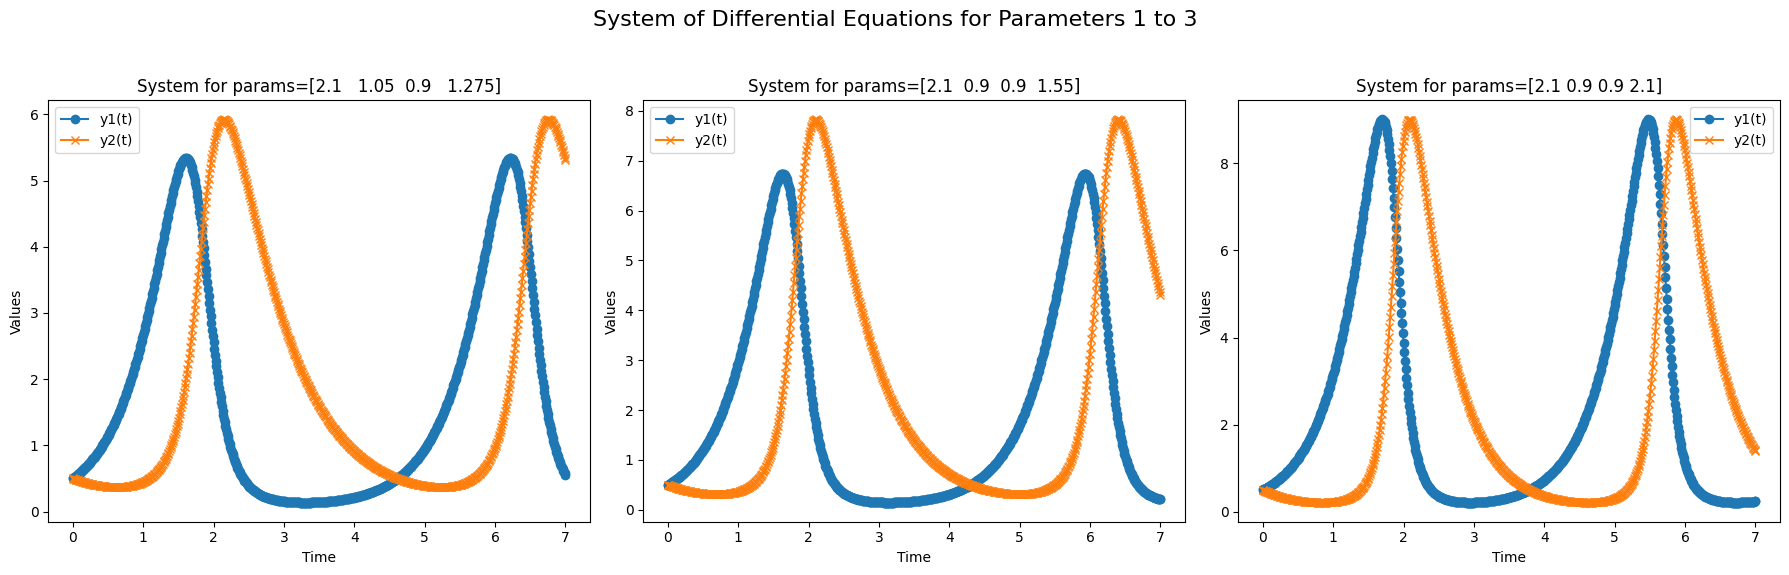

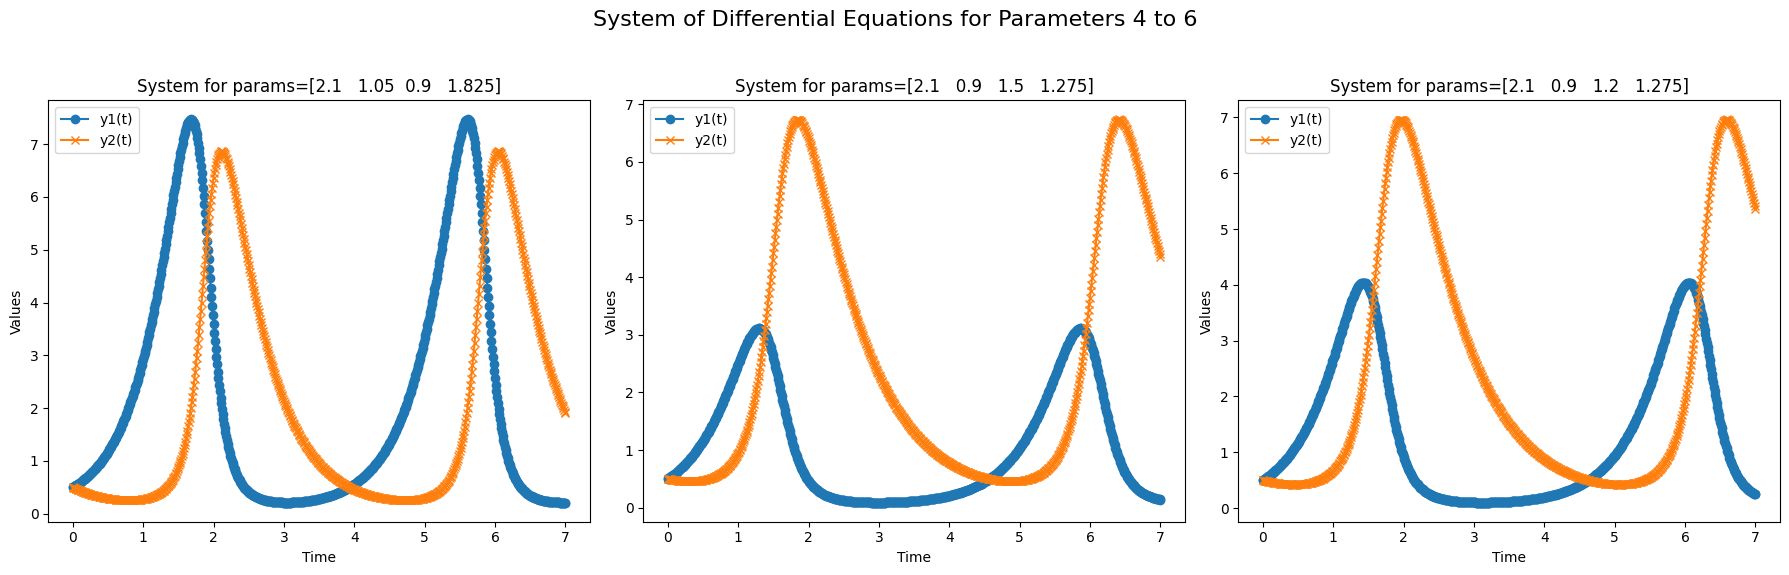

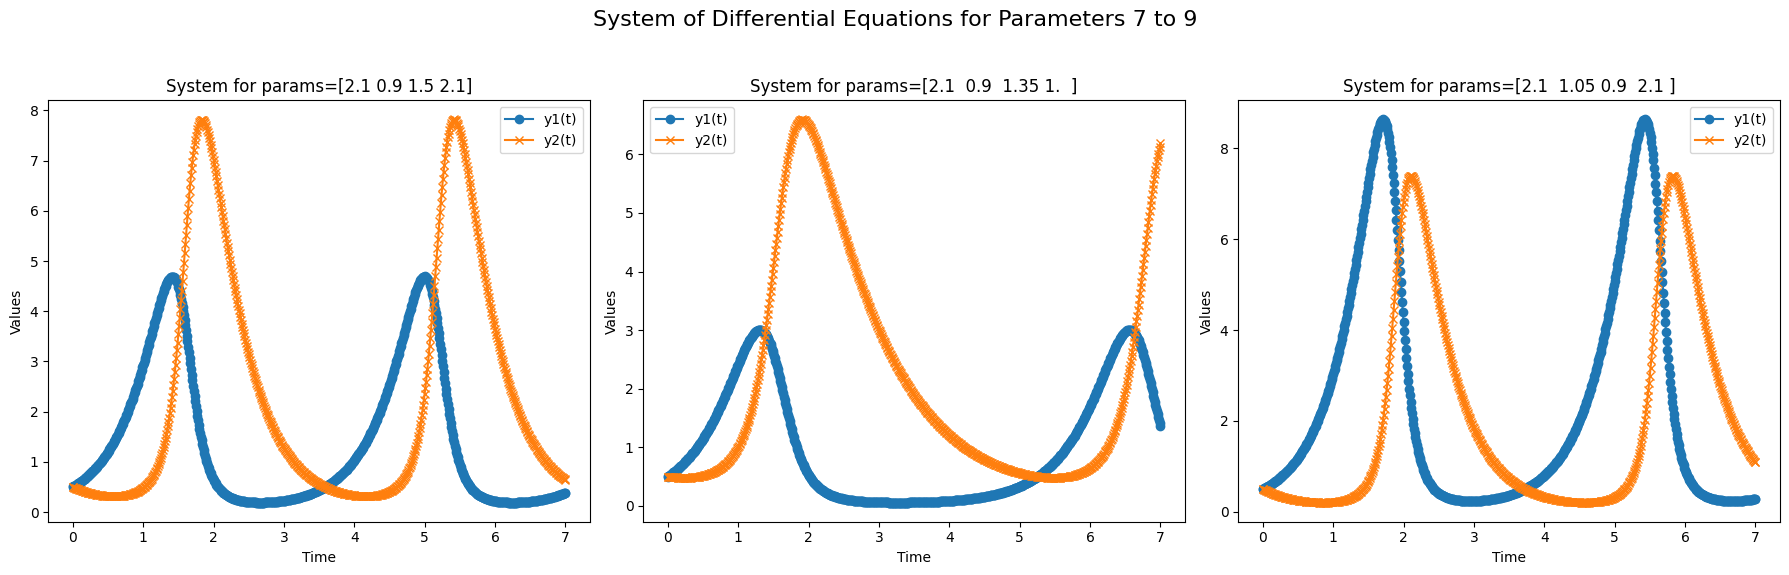

In [5]:
solver_valHF.plot_results()

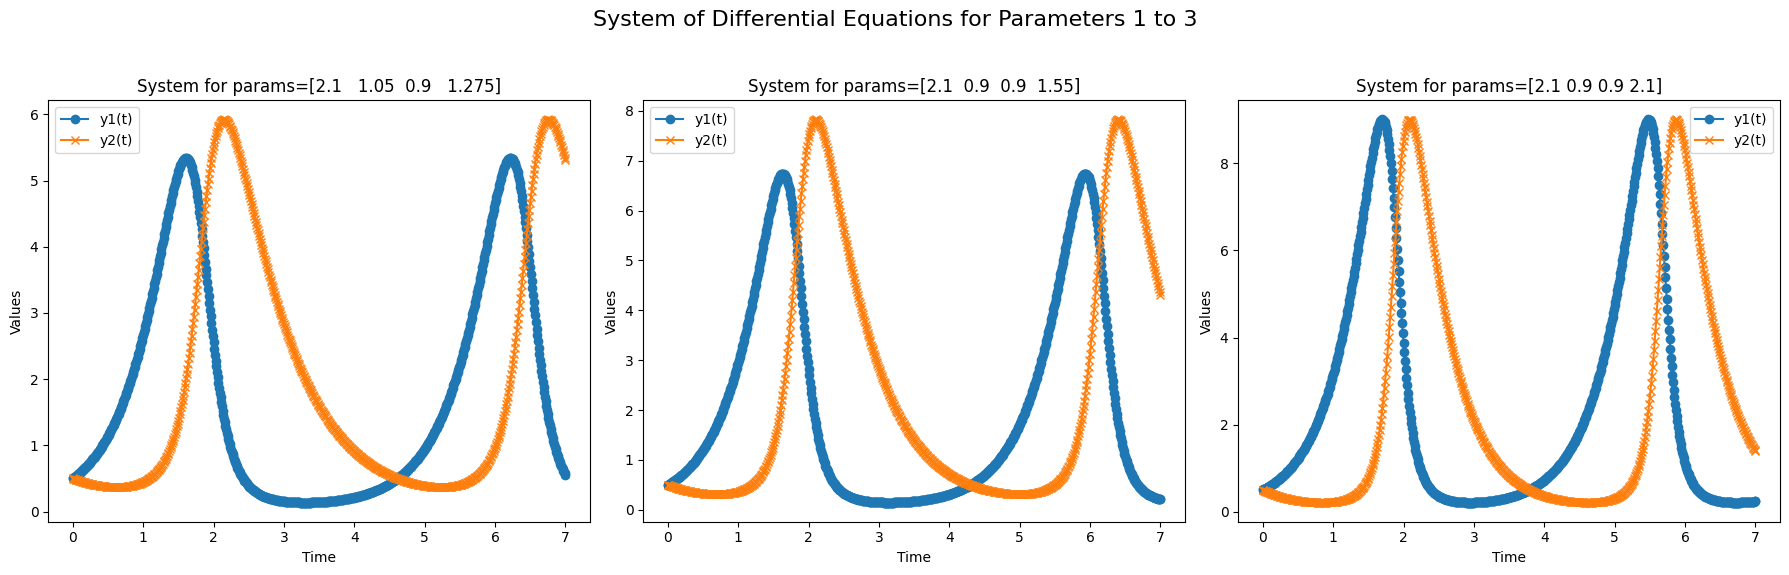

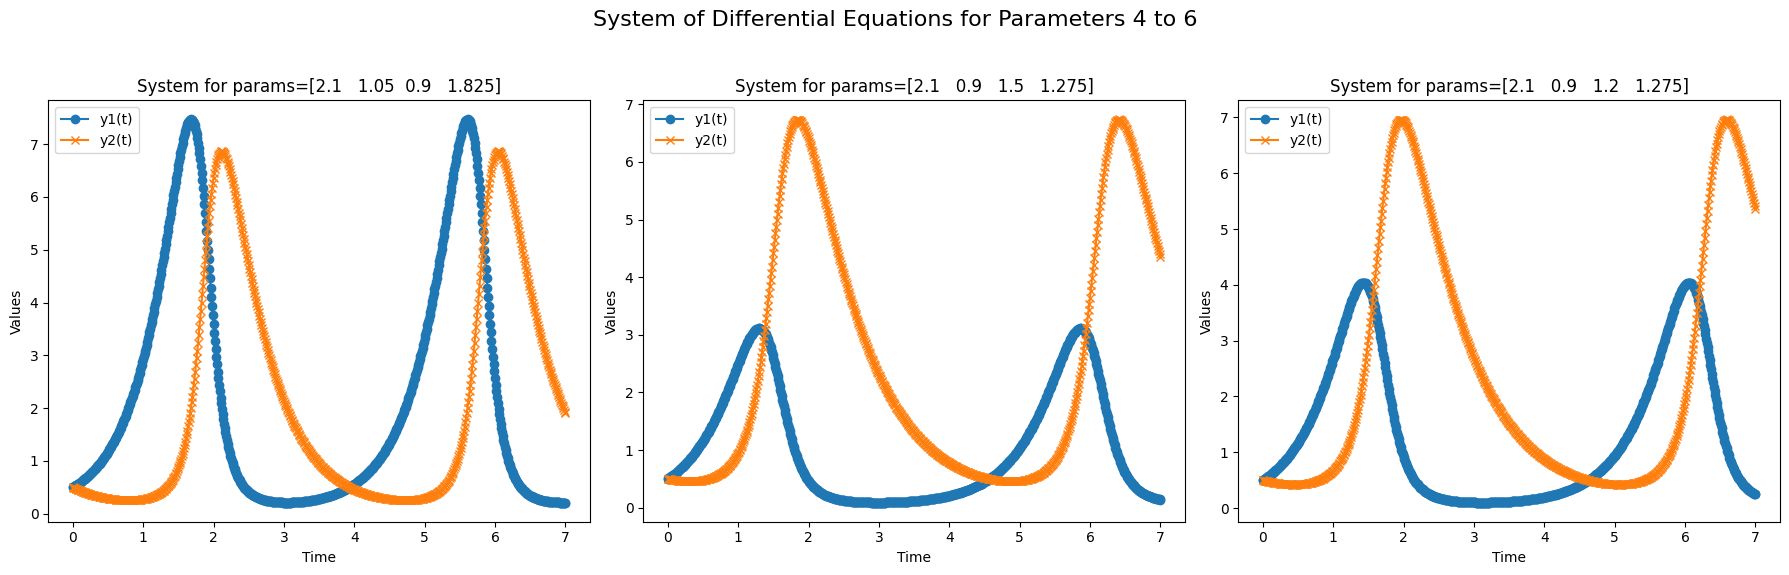

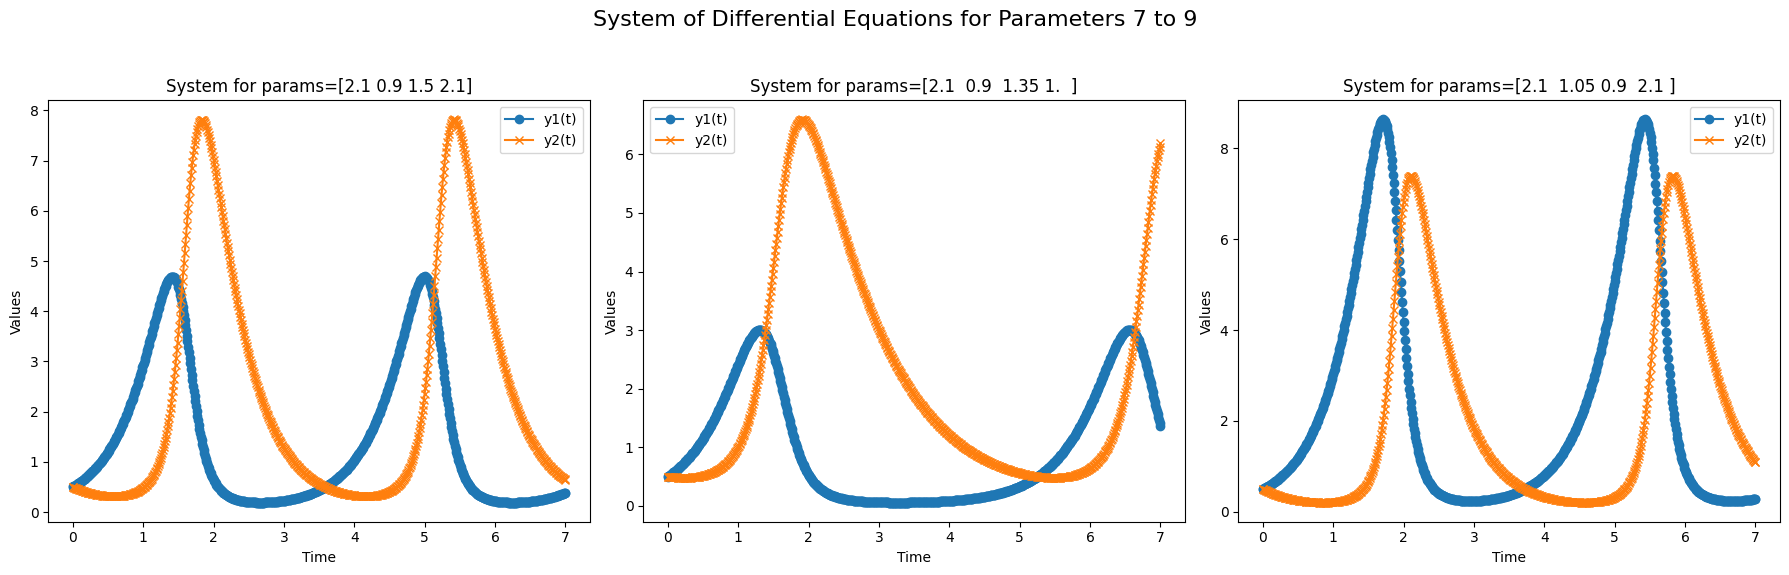

In [6]:
solver_HF.plot_results()

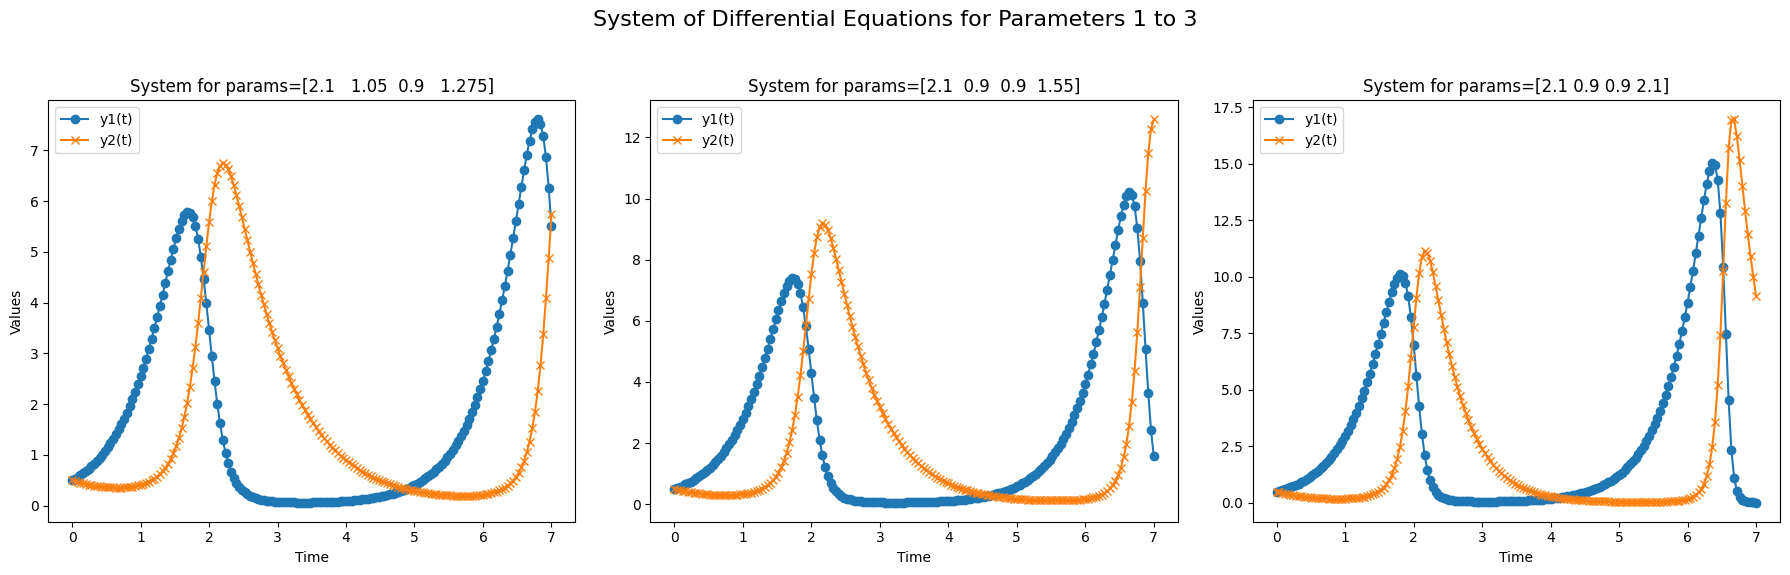

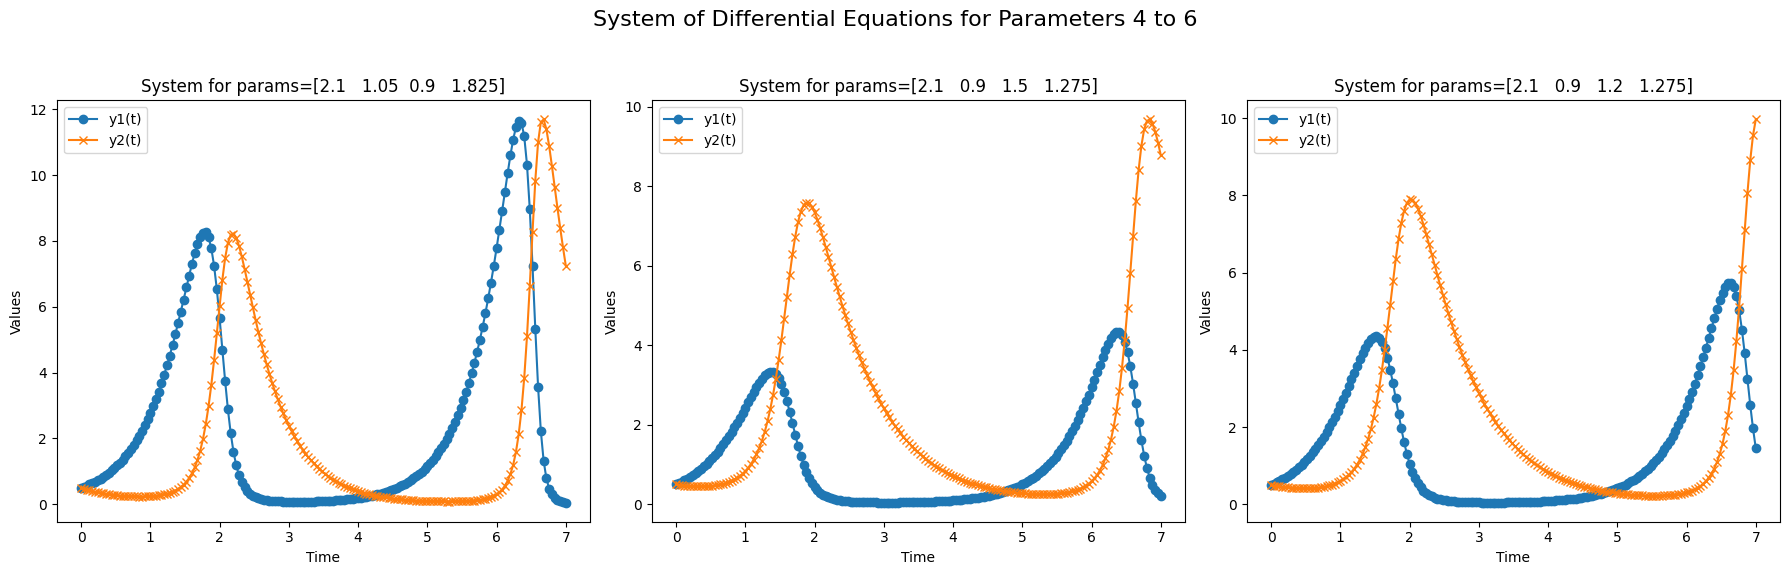

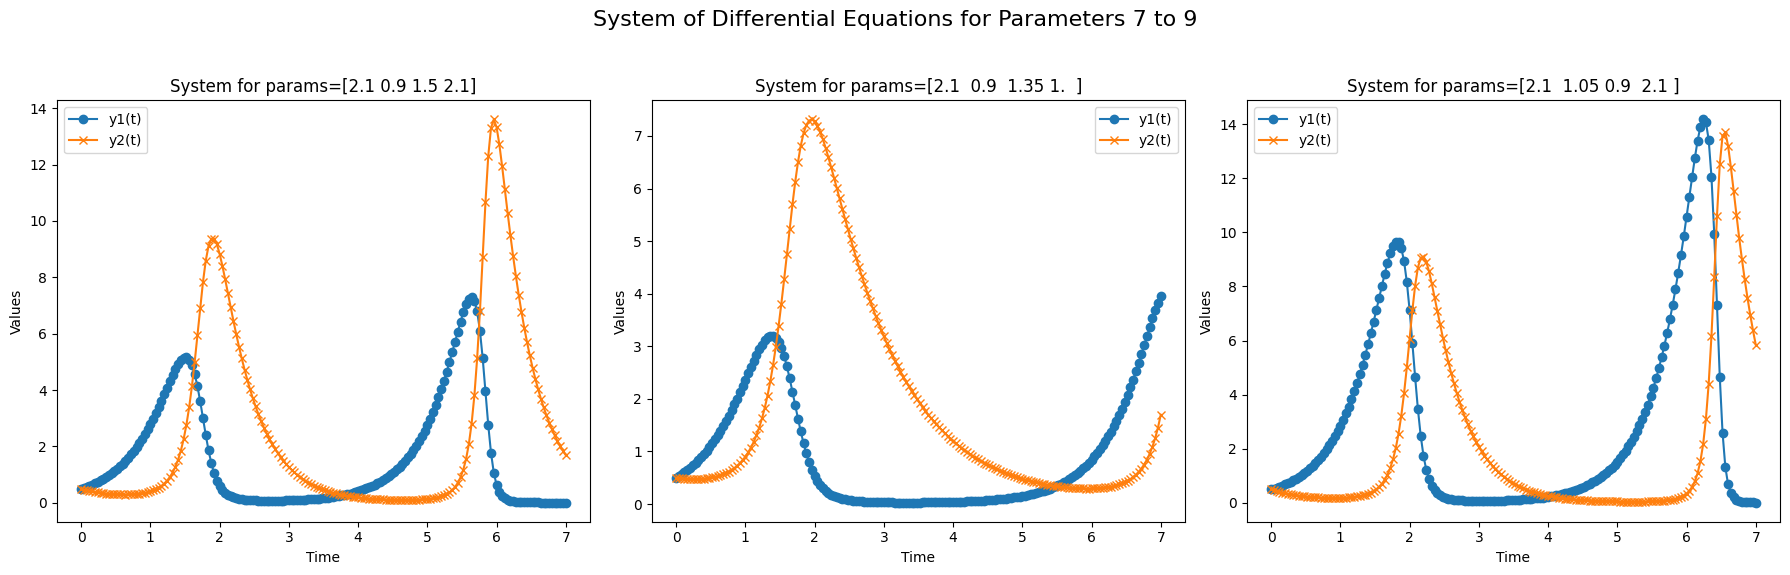

In [7]:
solver_LF.plot_results()

In [8]:
# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_HF.shape[0]), np.arange(t_HF.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
x_HF = np.hstack((t_HF[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_HF[cartesian_product_indices[:, 0]]))
#print(combined_vectors)


# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_LF.shape[0]), np.arange(t_LF.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
x_LF = np.hstack((t_LF[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_LF[cartesian_product_indices[:, 0]]))


In [9]:
# Create the Cartesian product of the indices
cartesian_product_indices_val = np.array(np.meshgrid(np.arange(mu_valHF.shape[0]), np.arange(t_valHF.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
x_valHF = np.hstack((t_valHF[cartesian_product_indices_val[:, 1]].reshape(-1, 1), mu_valHF[cartesian_product_indices_val[:, 0]]))
#print(combined_vectors)


# Create the Cartesian product of the indices
cartesian_product_indices_val = np.array(np.meshgrid(np.arange(mu_valLF.shape[0]), np.arange(t_valLF.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
x_valLF = np.hstack((t_valLF[cartesian_product_indices_val[:, 1]].reshape(-1, 1), mu_valLF[cartesian_product_indices_val[:, 0]]))

In [10]:
x_LF.shape

(1584, 5)

In [11]:
y_HF=np.array(y_HF).reshape(-1, solver_HF.get_dim())
y_LF=np.array(y_LF).reshape(-1, solver_LF.get_dim())


In [12]:
y_valHF=np.array(y_valHF).reshape(-1, solver_valHF.get_dim())
y_valLF=np.array(y_valLF).reshape(-1, solver_valLF.get_dim())

In [13]:
y_HF.shape

(6309, 2)

In [14]:
x_HF.shape

(6309, 5)

[I 2024-08-19 16:54:15,280] A new study created in RDB with name: no-name-43047dc7-d7ce-4875-9281-8da061f1728b
[I 2024-08-19 16:55:18,574] Trial 6 finished with value: 1.909366760303488 and parameters: {'nodes': 4, 'l2weight': 0.043306122213725005, 'lr': 0.0005240571286178494, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 6 with value: 1.909366760303488.
[I 2024-08-19 16:55:19,396] Trial 4 finished with value: 2.311731712437743 and parameters: {'nodes': 47, 'l2weight': 0.017688671568067433, 'lr': 0.03290577406468992, 'kernel_init': 'uniform', 'opt': 'Adamax'}. Best is trial 6 with value: 1.909366760303488.
[I 2024-08-19 16:55:19,811] Trial 2 finished with value: 0.411670165845821 and parameters: {'nodes': 58, 'l2weight': 0.023052445168045162, 'lr': 0.01257525657976397, 'kernel_init': 'uniform', 'opt': 'Adam'}. Best is trial 3 with value: 0.32492422917193264.
[I 2024-08-19 16:55:19,825] Trial 0 finished with value: 6.108259846694243 and parameters: {'nodes': 21, 'l2we

New parameters identified during HPO:
{'kernel_init': 'glorot_uniform',
 'l2weight': 0.0004356681067336297,
 'lr': 0.0067583019914394275,
 'nodes': 8,
 'opt': 'Adam'}
The function training took 27.938564 seconds.


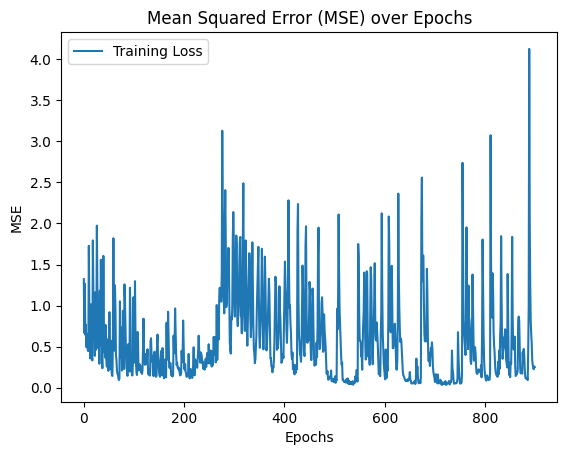

[I 2024-08-19 16:57:23,543] A new study created in RDB with name: no-name-9b4881bd-7d6c-492e-9719-a762d0407c81
[I 2024-08-19 16:58:00,151] Trial 9 finished with value: 1.7491942975562935 and parameters: {'nodes': 60, 'l2weight': 0.006520660209403835, 'lr': 0.00011204618665998806, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 9 with value: 1.7491942975562935.
[I 2024-08-19 16:58:00,815] Trial 3 finished with value: 2.2378468784145675 and parameters: {'nodes': 19, 'l2weight': 0.03125849901120426, 'lr': 0.0001424800413609713, 'kernel_init': 'uniform', 'opt': 'Adam'}. Best is trial 9 with value: 1.7491942975562935.
[I 2024-08-19 16:58:00,909] Trial 4 finished with value: 2.3018708439172446 and parameters: {'nodes': 4, 'l2weight': 0.012041295848565906, 'lr': 0.00010935221664311757, 'kernel_init': 'uniform', 'opt': 'Adam'}. Best is trial 1 with value: 1.279340715500016.
[I 2024-08-19 16:58:00,952] Trial 1 finished with value: 1.279340715500016 and parameters: {'nodes': 22,

New parameters identified during HPO:
{'kernel_init': 'glorot_uniform',
 'l2weight': 0.0011341792539862133,
 'lr': 0.027984034176103203,
 'nodes': 44,
 'opt': 'Adam'}
The function training took 13.673040 seconds.


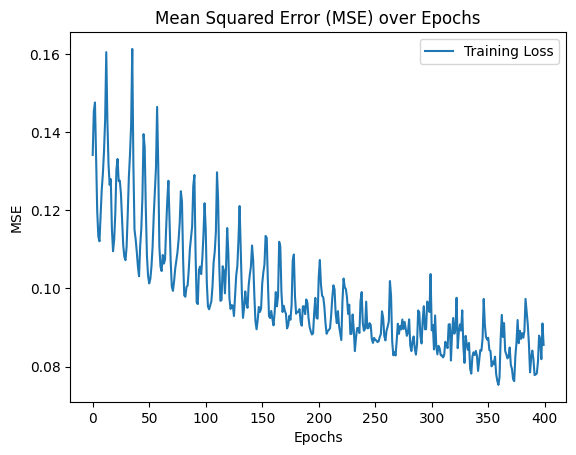

[I 2024-08-19 16:59:11,726] A new study created in RDB with name: no-name-068ef43f-b4ad-4315-8081-052ac6650f19
[I 2024-08-19 17:00:16,405] Trial 1 finished with value: 0.06677455334785723 and parameters: {'nodes': 5, 'l2weight': 0.002223637995579231, 'lr': 0.017566162146250706, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 1 with value: 0.06677455334785723.
[I 2024-08-19 17:00:18,013] Trial 0 finished with value: 0.0309161160037068 and parameters: {'nodes': 6, 'l2weight': 0.0034678275830700486, 'lr': 0.013890807773456726, 'kernel_init': 'glorot_uniform', 'opt': 'Adam'}. Best is trial 0 with value: 0.0309161160037068.
[I 2024-08-19 17:00:18,765] Trial 8 finished with value: 0.5690025137934889 and parameters: {'nodes': 4, 'l2weight': 0.005396456931159209, 'lr': 0.0013851219873948755, 'kernel_init': 'uniform', 'opt': 'Adamax'}. Best is trial 0 with value: 0.0309161160037068.
[I 2024-08-19 17:00:19,477] Trial 4 finished with value: 3.586609888399656 and parameters: {'nod

New parameters identified during HPO:
{'kernel_init': 'uniform',
 'l2weight': 0.008399926421197027,
 'lr': 0.04022076724860645,
 'nodes': 15,
 'opt': 'Adamax'}
The function training took 23.888658 seconds.


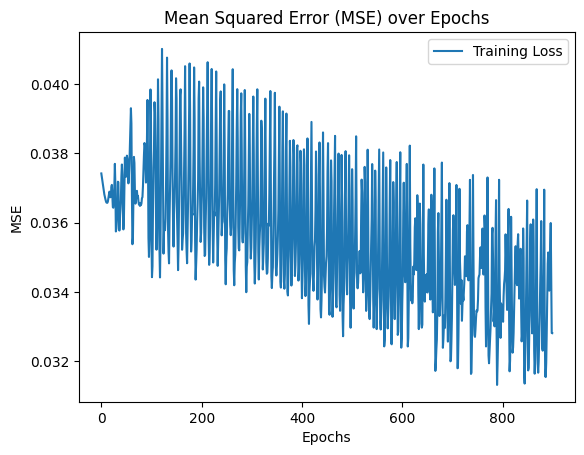

Test MSE: 0.10159259805955345
R^2: 0.9758439243745515


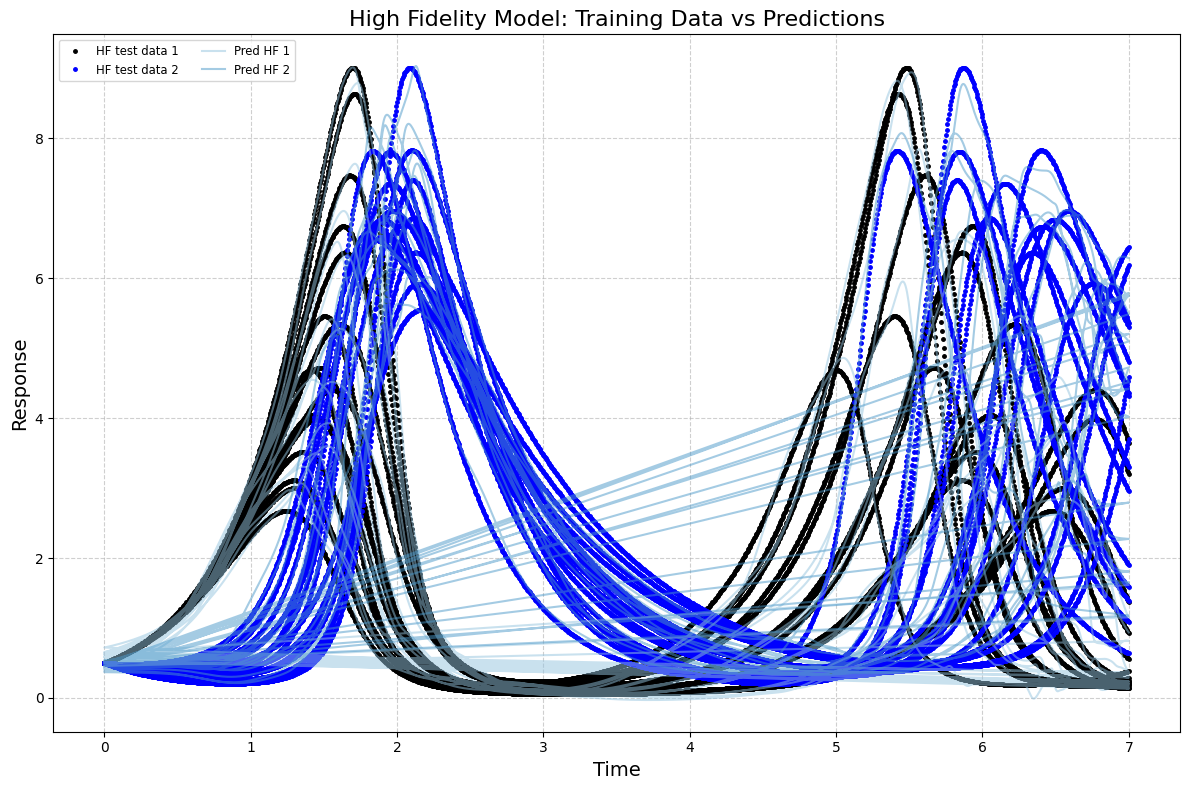

In [15]:
n_LF=700
indices_LF = np.random.permutation(x_LF.shape[0])[:n_LF]

n_Single=1500
indices_Single = np.random.permutation(x_HF.shape[0])[:n_Single]

n_HF=2000
indices_HF = np.random.permutation(x_HF.shape[0])[:n_HF]


n_valLF=500
indices_valLF = np.random.permutation(x_valLF.shape[0])[:n_valLF]

n_valSingle=1250
indices_valSingle = np.random.permutation(x_valHF.shape[0])[:n_valSingle]

n_valHF=1700
indices_valHF = np.random.permutation(x_valHF.shape[0])[:n_valHF]



N=[1000,500,1000]
#n=[500,1000]
n=[75,150,200]

names = ['LF','Single', 'HF']

# parameters 
bestLF_params = {
    "lr": 0.0255,
    "kernel_init": "glorot_uniform",
    "opt": "Adam",
} 
best_params_single={'kernel_init': 'uniform', 
             'l2weight': 0.005395541657336886, 
             'lr': 0.0025412188591473228,  
             'opt': 'Adamax'}

best_params={'kernel_init': 'uniform', 
             'l2weight': 0.005395541657336886, 
             'lr': 0.0025412188591473228, 
             'nodes': 12.0, 
             'opt': 'Adamax'}

params_NN=[bestLF_params,best_params_single, best_params]


# collection of the parameters
definition_2steps = {
    "network_type": "3step",
    "names": names,
    "params": params_NN,
    "data_train": [x_LF[indices_LF,:],x_HF[indices_Single,:],x_HF[indices_HF,:]],
    "output_train": [y_LF[indices_LF,:],  y_HF[indices_Single,:],y_HF[indices_HF,:]],
    "data_val": [x_valLF[indices_valLF,:],x_valHF[indices_valSingle,:],x_valHF[indices_valHF,:]],
    "output_val": [y_valLF[indices_valLF,:],  y_valHF[indices_valSingle,:],y_valHF[indices_valHF,:]],
    "N": N,
    "n": n,
    "train": True,
    "do_HPO": True,
    "verbose": False
}

final_model = NetworkFactory.build_network(**definition_2steps)

solver_test=System2()
params_values_test = combinations_array[0:16,:]
(t_test,y_test,mu_test)=solver_test.generate_dataset(T=7.0, params=params_values_test, h=0.005, fidelity='HF')
solver_test.save_dataset('dataset_test_4params.h5')



# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_test.shape[0]), np.arange(t_test.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
datatest = np.hstack((t_test[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_test[cartesian_product_indices[:, 0]]))
#print(combined_vectors)


y_test_pred=final_model.prediction(datatest)

(mse_MF,R_MF)=final_model.performance(datatest,np.array(y_test).reshape(-1,solver_test.get_dim()))


plt.figure(figsize=(12, 8))

# Plotting the training data with darker markers
plt.plot(datatest[:, 0], np.array(y_test).reshape(-1,solver_test.get_dim())[:, 0], 'k.', label='HF test data 1', markersize=5)  # Nero
plt.plot(datatest[:, 0], np.array(y_test).reshape(-1,solver_test.get_dim())[:, 1], 'b.', label='HF test data 2', markersize=5)  # Blu scuro

# Plotting the prediction data with lighter, less fluorescent colors
for i in range(y_test_pred.shape[1]):
    plt.plot(datatest[:, 0], y_test_pred[:, i], '-', 
             color=plt.cm.Blues(0.4 + 0.4 * i / y_test_pred.shape[1]),  # Gamma di blu meno vividi
             alpha=0.5, label=f'Pred HF {i+1}', linewidth=1.5)  # Trasparenza ridotta e linee più sottili

# Adding grid to the plot
plt.grid(True, linestyle='--', alpha=0.6)

# Adding labels to the axes
plt.xlabel('Time', fontsize=14)
plt.ylabel('Response', fontsize=14)

# Enhancing the title
plt.title('High Fidelity Model: Training Data vs Predictions', fontsize=16)

# Improving the legend
plt.legend(loc='best', fontsize='small', ncol=2)

# Adjusting the layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

The function training took 47.495545 seconds.


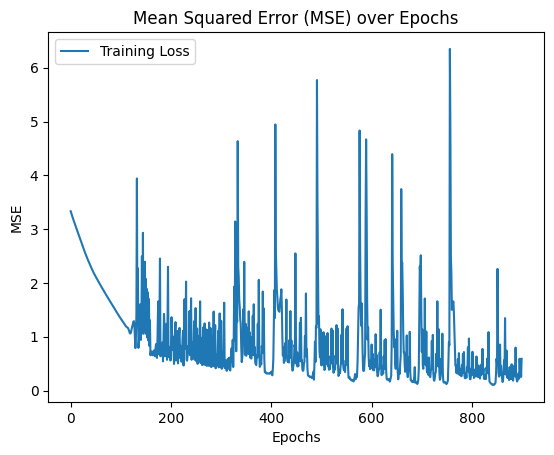

The function training took 24.768109 seconds.


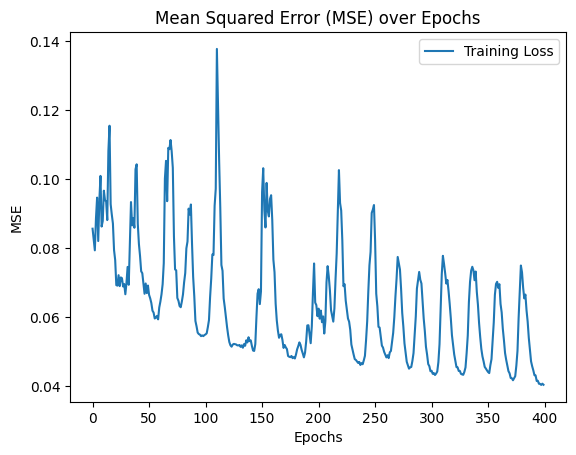

The function training took 38.447821 seconds.


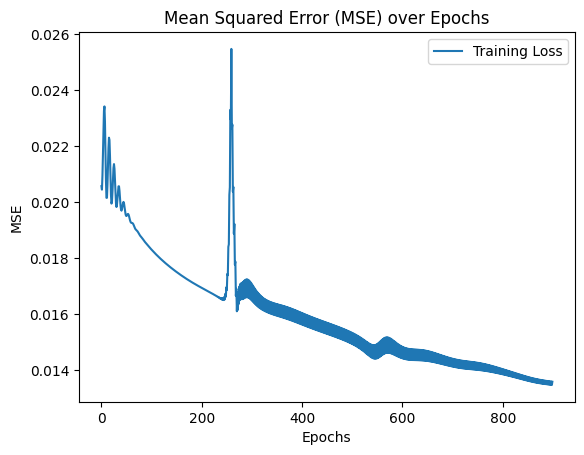

Test MSE: 0.16348023435204087
R^2: 0.9634880386961828


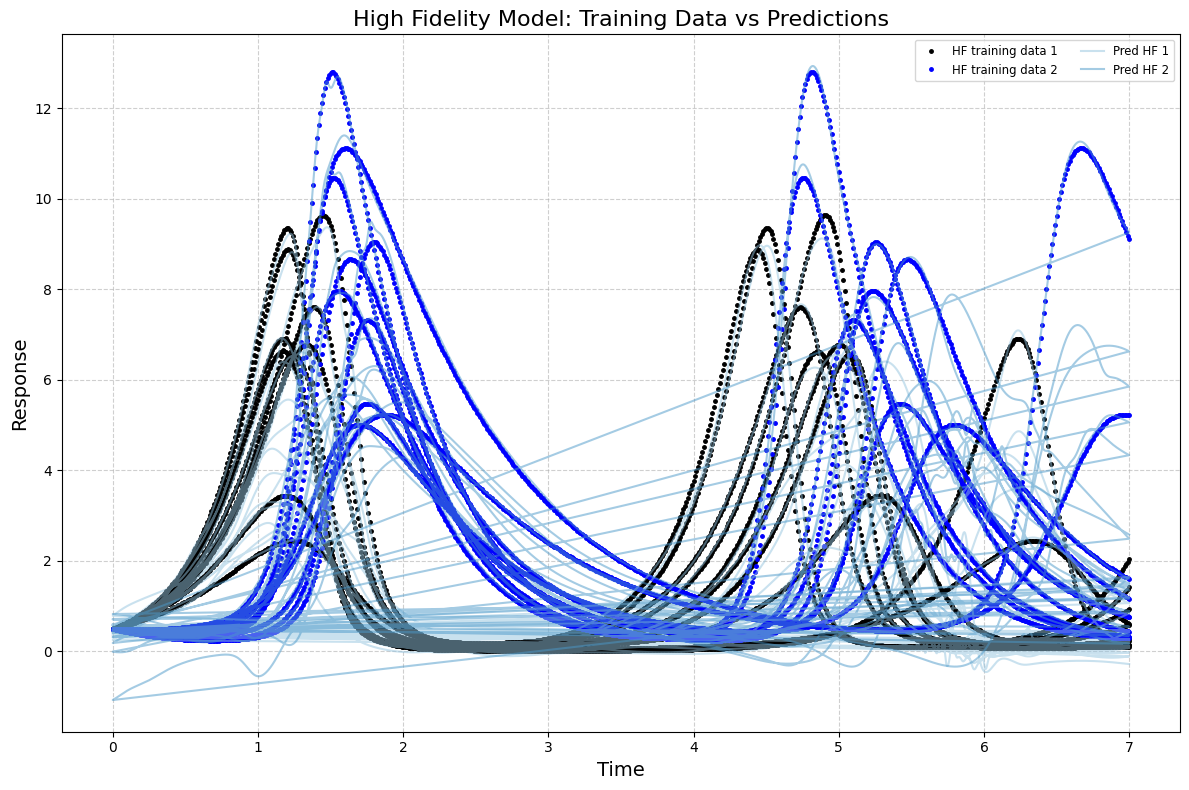

In [8]:
n_LF=700
indices_LF = np.random.permutation(x_LF.shape[0])[:n_LF]

n_Single=1500
indices_Single = np.random.permutation(x_HF.shape[0])[:n_Single]

n_HF=2000
indices_HF = np.random.permutation(x_HF.shape[0])[:n_HF]

N=[1000,500,1000]
#n=[500,1000]
n=[75,150,200]

names = ['LF','Single', 'HF']

# parameters 
bestLF_params = {'kernel_init': 'glorot_uniform',
 'l2weight': 0.009439001042229658,
 'lr': 0.001547841664661148,
 'nodes': 8,
 'opt': 'Adam'} 
best_params_single={'kernel_init': 'uniform',
 'l2weight': 0.000258392824624208,
 'lr': 0.014543316764914976,
 'nodes': 5,
 'opt': 'Adam'}

best_params={'kernel_init': 'uniform',
 'l2weight': 0.00021648620511098636,
 'lr': 0.023156568390181882,
 'nodes': 8,
 'opt': 'Adam'}

params_NN=[bestLF_params,best_params_single, best_params]


# collection of the parameters
definition_2steps = {
    "network_type": "3step",
    "names": names,
    "params": params_NN,
    "data_train": [x_LF[indices_LF,:],x_HF[indices_Single,:],x_HF[indices_HF,:]],
    "output_train": [y_LF[indices_LF,:],  y_HF[indices_Single,:],y_HF[indices_HF,:]],
    "N": N,
    "n": n,
    "train": True,
    "do_HPO": False,
    "verbose": False
}

final_model = NetworkFactory.build_network(**definition_2steps)

solver_test=System2()
params_values_test = combinations_array[0:20,:]
(t_test,y_test,mu_test)=solver_test.generate_dataset(T=7.0, params=params_values_test, h=0.005, fidelity='HF')
solver_test.save_dataset('dataset_test_4params.h5')



# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_test.shape[0]), np.arange(t_test.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
datatest = np.hstack((t_test[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_test[cartesian_product_indices[:, 0]]))
#print(combined_vectors)


y_test_pred=final_model.prediction(datatest)

(mse_MF,R_MF)=final_model.performance(datatest,np.array(y_test).reshape(-1,solver_test.get_dim()))


plt.figure(figsize=(12, 8))

# Plotting the training data with darker markers
plt.plot(x_HF[:, 0], y_HF[:, 0], 'k.', label='HF training data 1', markersize=5)  # Nero
plt.plot(x_HF[:, 0], y_HF[:, 1], 'b.', label='HF training data 2', markersize=5)  # Blu scuro

# Plotting the prediction data with lighter, less fluorescent colors
for i in range(y_test_pred.shape[1]):
    plt.plot(datatest[:, 0], y_test_pred[:, i], '-', 
             color=plt.cm.Blues(0.4 + 0.4 * i / y_test_pred.shape[1]),  # Gamma di blu meno vividi
             alpha=0.5, label=f'Pred HF {i+1}', linewidth=1.5)  # Trasparenza ridotta e linee più sottili

# Adding grid to the plot
plt.grid(True, linestyle='--', alpha=0.6)

# Adding labels to the axes
plt.xlabel('Time', fontsize=14)
plt.ylabel('Response', fontsize=14)

# Enhancing the title
plt.title('High Fidelity Model: Training Data vs Predictions', fontsize=16)

# Improving the legend
plt.legend(loc='best', fontsize='small', ncol=2)

# Adjusting the layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

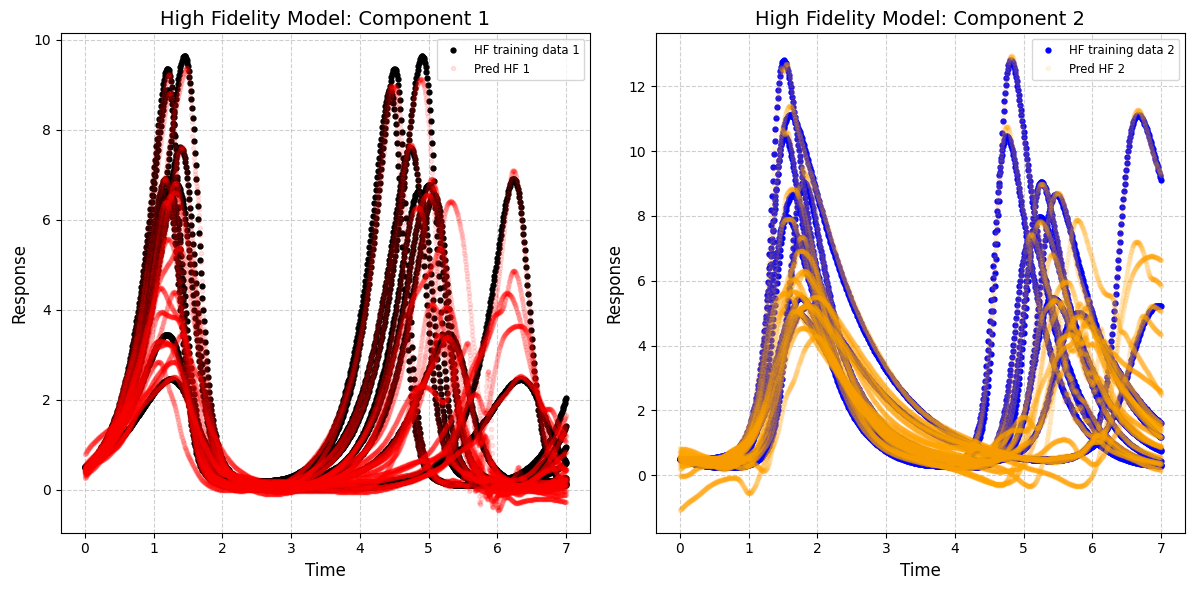

In [14]:
components = ['Component 1', 'Component 2']
colors_training = ['k', 'b', 'g']  # Nero, Blu scuro, Verde scuro
colors_pred = ['r', 'orange', 'purple']  # Rosso, Arancione, Viola

plt.figure(figsize=(18, 6))

# Loop through each component to create a separate plot
for i in range(2):
    plt.subplot(1, 3, i + 1)  # Create a subplot (1 row, 3 columns)
    
    # Plotting the training data for the i-th component
    plt.plot(x_HF[:, 0], y_HF[:, i], f'{colors_training[i]}.', label=f'HF training data {i + 1}', markersize=7)

    # Plotting the prediction data for the i-th component
    plt.plot(datatest[:, 0], y_test_pred[:, i], '.', 
             color=colors_pred[i], alpha=0.1, label=f'Pred HF {i + 1}', linewidth=3)
    
    # Adding grid, labels, and title
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('Response', fontsize=12)
    plt.title(f'High Fidelity Model: {components[i]}', fontsize=14)
    
    # Add a legend
    plt.legend(loc='best', fontsize='small')

# Adjust the layout and show the plot
plt.tight_layout()
plt.show()

Sampling chain 1/2


Running chain, α = 0.53: 100%|██████████| 30/30 [01:01<00:00,  2.05s/it]


Sampling chain 2/2


Running chain, α = 0.33: 100%|██████████| 30/30 [01:00<00:00,  2.00s/it]


Estimated values are [2.329 0.929 0.478 1.319]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.329  0.036   2.271    2.363      0.012    0.009       9.0      14.0   
x1  0.929  0.036   0.871    0.963      0.012    0.009       9.0      14.0   
x2  0.478  0.036   0.420    0.513      0.012    0.009       9.0      14.0   
x3  1.319  0.036   1.261    1.354      0.012    0.009       9.0      14.0   

    r_hat  
x0   1.34  
x1   1.34  
x2   1.34  
x3   1.34  
The difference between estimated values [0.671 0.271 0.872 0.506]



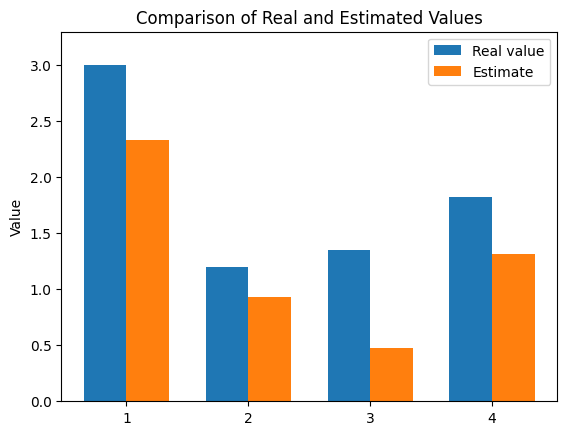

The function param_inverse took 214.053598 seconds.


KeyboardInterrupt: 

In [9]:
mean_prior =np.array([2.3,0.9,0.4,1.1])
cov_prior=np.diag([ 0.1, 0.01, 0.01, 0.1])

sigma_noise = [0.25,0.5]
n_data = [50,30]
parameters =np.array([3.,1.2,1.35,1.825])
sigma = np.array([ 4.,2.])
rwmh_scaling = np.array([ 2.,0.5,1.])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 30
burnin = 20
n_chains = 2
algo = "MH"

module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)

estimateMF, errorMF, param_resultsMF= run_simulation(x_HF, mean_prior, cov_prior, y_HF, sigma_noise, n_data, parameters,  sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, final_model,algo,subsampling_rate=5, levels=3,force_sequential=True)


In [ ]:
mean_prior =np.array([2.3,0.9,0.4,1.1])
cov_prior=np.diag([ 0.1, 0.01, 0.01, 0.1])

sigma_noise = [0.25,0.5]
n_data = [50,30]
parameters =np.array([3.,1.2,1.35,1.825])
sigma = np.array([ 4.,2.])
rwmh_scaling = np.array([ 2.,0.5,1.])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 30
burnin = 20
n_chains = 2
algo = "MH"

module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)

estimateMF, errorMF, param_resultsMF= run_simulation(x_HF, mean_prior, cov_prior, y_HF, sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, final_model,algo, subsampling_rate=5,levels=3,force_sequential=True)


In [ ]:
mean_prior =np.array([2.3,0.9,0.4,1.1])
cov_prior=np.diag([ 0.1, 0.01, 0.01, 0.1])

sigma_noise = [0.25,0.5]
n_data = [50,30]
parameters =np.array([3.,1.2,1.35,1.825])
sigma = np.array([ 4.,2.])
rwmh_scaling = np.array([ 2.,0.5,1.])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 3000
burnin = 2000
n_chains = 2
algo = "AM"

module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)

estimateMF, errorMF, param_resultsMF= run_simulation(x_HF, mean_prior, cov_prior, y_HF, sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, final_model,algo, force_sequential=True)


In [ ]:
mean_prior =np.array([2.3,0.9,0.4,1.1])
cov_prior=np.diag([ 0.1, 0.01, 0.01, 0.1])

sigma_noise = [0.25,0.5]
n_data = [50,30]
parameters =np.array([3.,1.2,1.35,1.825])
sigma = np.array([ 4.,2.])
rwmh_scaling = np.array([ 2.,0.5,1.])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 3000
burnin = 2000
n_chains = 2
algo = "DREAMZ"

module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)

estimateMF, errorMF, param_resultsMF= run_simulation(x_HF, mean_prior, cov_prior, y_HF, sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, final_model,algo, force_sequential=True)

In [ ]:
mean_prior =np.array([2.3,0.9,0.4,1.1])
cov_prior=np.diag([ 0.1, 0.01, 0.01, 0.1])

sigma_noise = [0.25,0.5]
n_data = [50,30]
parameters =np.array([3.,1.2,1.35,1.825])
sigma = np.array([ 4.,2.])
rwmh_scaling = np.array([ 2.,0.5,1.])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 3000
burnin = 2000
n_chains = 2
algo = "MH"

module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)

estimateMF, errorMF, param_resultsMF= run_simulation(x_HF, mean_prior, cov_prior, y_HF, sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, final_model,algo,force_sequential=True)
